# 08 - VUS Prioritization & Ranking

Scores unlabeled VUS rows with the trained model and combines model score
with enrichment, phenotype, and segregation signals for final ranking.

This output is for prioritization, not diagnosis.

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / 'data'
REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

IN_MODEL = ROOT / 'models' / 'vus_ranker.joblib'
IN_X_VUS = DATA_DIR / 'vus_unlabeled_X.parquet'
IN_META_VUS = DATA_DIR / 'vus_unlabeled_meta.csv'

OUT_RANKED = DATA_DIR / 'vus_priority_ranking.csv'
OUT_TOP_TRIO = REPORTS_DIR / 'vus_top10_per_trio.csv'
OUT_TOP_GENE = REPORTS_DIR / 'vus_top5_per_gene.csv'
OUT_RANKED_GENE = REPORTS_DIR / 'vus_ranked_per_gene.csv'

print('ROOT:', ROOT)

ROOT: C:\Users\lvrga\OneDrive\work\predtest


In [4]:
X_vus = pd.read_parquet(IN_X_VUS)
meta = pd.read_csv(IN_META_VUS)
model = joblib.load(IN_MODEL)

print('VUS feature shape:', X_vus.shape)
print('VUS metadata shape:', meta.shape)

if X_vus.empty:
    raise ValueError('No VUS rows available. Run notebook 06 after loading data with VUS.')

if len(meta) != len(X_vus):
    raise ValueError('Meta and feature rows are misaligned.')

VUS feature shape: (4750, 38)
VUS metadata shape: (4750, 6)


In [5]:
def minmax(series: pd.Series) -> pd.Series:
    s = series.astype(float)
    lo, hi = s.min(), s.max()
    if pd.isna(lo) or pd.isna(hi) or hi <= lo:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - lo) / (hi - lo)

def positive_class_proba(estimator, X_input: pd.DataFrame) -> pd.Series:
    proba = estimator.predict_proba(X_input)
    if hasattr(estimator, 'named_steps') and 'clf' in estimator.named_steps:
        classes = getattr(estimator.named_steps['clf'], 'classes_', None)
    else:
        classes = getattr(estimator, 'classes_', None)

    if proba.shape[1] == 1:
        if classes is None or len(classes) != 1:
            only_class = 0
        else:
            only_class = int(classes[0])
        vals = np.ones(len(X_input), dtype=float) if only_class == 1 else np.zeros(len(X_input), dtype=float)
        return pd.Series(vals, index=X_input.index, name='model_pathogenic_proba')

    if classes is not None:
        pos_idx = np.where(np.array(classes) == 1)[0]
        if len(pos_idx) == 1:
            return pd.Series(proba[:, int(pos_idx[0])], index=X_input.index, name='model_pathogenic_proba')

    # Fallback for estimators with standard [0,1] class order.
    return pd.Series(proba[:, 1], index=X_input.index, name='model_pathogenic_proba')

model_score = positive_class_proba(model, X_vus)

enrichment_raw = X_vus.get('gene_pos_rate', pd.Series(0.5, index=X_vus.index)).astype(float)
if 'gene_log_or' in X_vus.columns:
    enrichment_raw = enrichment_raw + 0.1 * X_vus['gene_log_or'].astype(float)
enrichment_score = minmax(enrichment_raw).rename('enrichment_score')

phenotype_score = minmax(X_vus.get('hpo_overlap_score', pd.Series(0.0, index=X_vus.index))).rename('phenotype_score')

seg = pd.Series(0.0, index=X_vus.index)
seg = seg + 1.0 * X_vus.get('inh_de_novo', pd.Series(0, index=X_vus.index)).astype(float)
seg = seg + 0.9 * X_vus.get('inh_autosomal_recessive', pd.Series(0, index=X_vus.index)).astype(float)
seg = seg + 0.8 * X_vus.get('inh_de_novo_hom', pd.Series(0, index=X_vus.index)).astype(float)
seg = seg + 0.4 * X_vus.get('inh_maternal', pd.Series(0, index=X_vus.index)).astype(float)
seg = seg + 0.4 * X_vus.get('inh_paternal', pd.Series(0, index=X_vus.index)).astype(float)
segregation_score = minmax(seg).rename('segregation_score')

final_score = (
    0.60 * model_score +
    0.15 * enrichment_score +
    0.15 * phenotype_score +
    0.10 * segregation_score
).rename('vus_priority_score')

ranked = meta.copy()
ranked['model_pathogenic_proba'] = model_score.values
ranked['enrichment_score'] = enrichment_score.values
ranked['phenotype_score'] = phenotype_score.values
ranked['segregation_score'] = segregation_score.values
ranked['vus_priority_score'] = final_score.values

# Merge resolved genomic coordinates
coords_file = DATA_DIR / 'vus_coords_resolved.csv'
if coords_file.exists():
    coords = pd.read_csv(coords_file)
    ranked = ranked.merge(coords[['row_id', 'HGVS_Coding', 'Chr', 'Position', 'Ref', 'Alt']], on='row_id', how='left')
    cols_order = [
        'trio_id', 'Sample', 'Gene', 'HGVS_Coding', 'Chr', 'Position', 'Ref', 'Alt',
        'Classification', 'inheritance_mode', 'row_id', 'model_pathogenic_proba',
        'enrichment_score', 'phenotype_score', 'segregation_score', 'vus_priority_score'
    ]
    cols_order = [c for c in cols_order if c in ranked.columns] + [c for c in ranked.columns if c not in cols_order]
    ranked = ranked[cols_order]

ranked = ranked.sort_values('vus_priority_score', ascending=False).reset_index(drop=True)

ranked.head(15)

,trio_id,Sample,Gene,Classification,inheritance_mode,row_id,model_pathogenic_proba,enrichment_score,phenotype_score,segregation_score,vus_priority_score
0,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1188,1.0,1.0,1.0,1.0,1.0
1,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1298,1.0,1.0,1.0,1.0,1.0
2,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1308,1.0,1.0,1.0,1.0,1.0
3,T15,SYNTH15_proband,MUC4,Uncertain significance,de_novo,4426,1.0,1.0,1.0,1.0,1.0
4,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1349,1.0,1.0,1.0,1.0,1.0
5,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1355,1.0,1.0,1.0,1.0,1.0
6,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1370,1.0,1.0,1.0,1.0,1.0
7,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1427,1.0,1.0,1.0,1.0,1.0
8,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1438,1.0,1.0,1.0,1.0,1.0
9,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1448,1.0,1.0,1.0,1.0,1.0


In [6]:
ranked.to_csv(OUT_RANKED, index=False)

if 'trio_id' in ranked.columns:
    top_per_trio = ranked.groupby('trio_id', as_index=False, group_keys=False).head(10)
else:
    top_per_trio = ranked.head(50).copy()
top_per_trio.to_csv(OUT_TOP_TRIO, index=False)

if 'Gene' in ranked.columns:
    top_per_gene = ranked.groupby('Gene', as_index=False, group_keys=False).head(5)
    ranked_per_gene = ranked.sort_values(['Gene', 'vus_priority_score'], ascending=[True, False]).reset_index(drop=True)
else:
    top_per_gene = ranked.head(50).copy()
    ranked_per_gene = ranked.copy()
top_per_gene.to_csv(OUT_TOP_GENE, index=False)
ranked_per_gene.to_csv(OUT_RANKED_GENE, index=False)

print('Saved full ranking :', OUT_RANKED)
print('Saved per-trio top :', OUT_TOP_TRIO)
print('Saved per-gene top :', OUT_TOP_GENE)
print('Saved per-gene ranked :', OUT_RANKED_GENE)

Saved full ranking : C:\Users\lvrga\OneDrive\work\predtest\data\vus_priority_ranking.csv
Saved per-trio top : C:\Users\lvrga\OneDrive\work\predtest\reports\vus_top10_per_trio.csv
Saved per-gene top : C:\Users\lvrga\OneDrive\work\predtest\reports\vus_top5_per_gene.csv


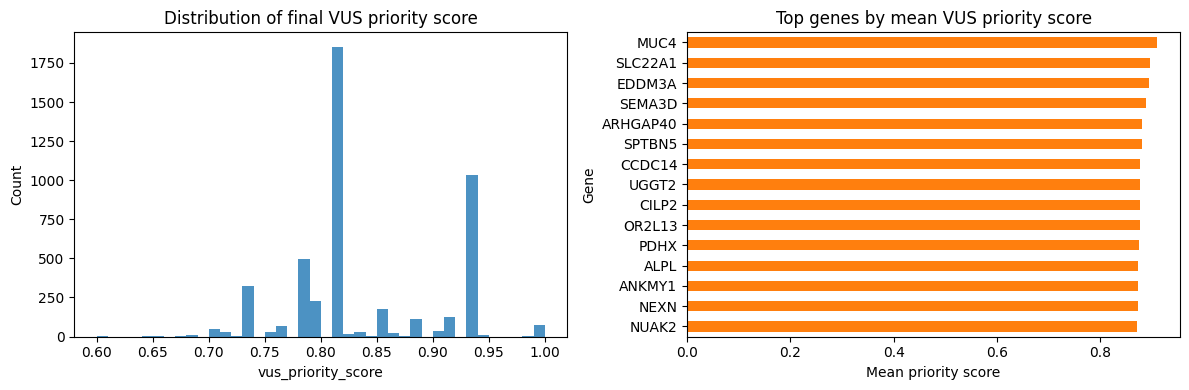

,trio_id,Sample,Gene,Classification,inheritance_mode,row_id,model_pathogenic_proba,enrichment_score,phenotype_score,segregation_score,vus_priority_score
0,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1188,1.0,1.0,1.0,1.0,1.0
1,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1298,1.0,1.0,1.0,1.0,1.0
2,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1308,1.0,1.0,1.0,1.0,1.0
3,T15,SYNTH15_proband,MUC4,Uncertain significance,de_novo,4426,1.0,1.0,1.0,1.0,1.0
4,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1349,1.0,1.0,1.0,1.0,1.0
5,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1355,1.0,1.0,1.0,1.0,1.0
6,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1370,1.0,1.0,1.0,1.0,1.0
7,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1427,1.0,1.0,1.0,1.0,1.0
8,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1438,1.0,1.0,1.0,1.0,1.0
9,T05,SYNTH05_proband,MUC4,Uncertain significance,de_novo,1448,1.0,1.0,1.0,1.0,1.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ranked['vus_priority_score'], bins=40, color='tab:blue', alpha=0.8)
axes[0].set_title('Distribution of final VUS priority score')
axes[0].set_xlabel('vus_priority_score')
axes[0].set_ylabel('Count')

if 'Gene' in ranked.columns:
    top_gene_plot = ranked.groupby('Gene')['vus_priority_score'].mean().sort_values(ascending=False).head(15)
    top_gene_plot.iloc[::-1].plot(kind='barh', ax=axes[1], color='tab:orange')
    axes[1].set_title('Top genes by mean VUS priority score')
    axes[1].set_xlabel('Mean priority score')
else:
    axes[1].axis('off')

plt.tight_layout()
plt.show()

display(ranked.head(20))